<a href="https://colab.research.google.com/github/Mayar-alsulami/Final_Project/blob/main/03_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For the "Math Basics" tasks (comparing manual vs. automated)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity  # -> Googled that too. i wanted to try new things instead of regular libraries


df = pd.read_csv('/content/drive/MyDrive/openpowerlifting_cleaned&features (1).csv')
df.head()

,Age,Sex,BodyweightKg,TotalKg,Equipment_Raw,Equipment_Single-ply,Equipment_Straps,Equipment_Wraps,Age_Weight_Ratio,Age_Bodyweight_Interaction,Is_Heavyweight,Using_Equipment,Heavyweight_Gear_Boost,Age_log,AgeGroup_Junior,AgeGroup_Adult,AgeGroup_Mature
0,47,0,59.60,138.35,0,0,0,1,0.788591,2801.20,0,1,0,2.127600,0,0,1
1,42,0,58.51,401.42,0,1,0,0,0.717826,2457.42,0,1,0,1.647680,0,0,1
2,42,0,58.51,95.25,1,0,0,0,0.717826,2457.42,0,0,0,1.647680,0,0,1
3,18,0,63.68,122.47,1,0,0,0,0.282663,1146.24,0,0,0,-1.915747,1,0,0
4,28,0,62.41,392.36,0,0,0,1,0.448646,1747.48,0,1,0,-0.070875,0,1,0


Text(0, 0.5, 'Frequency')

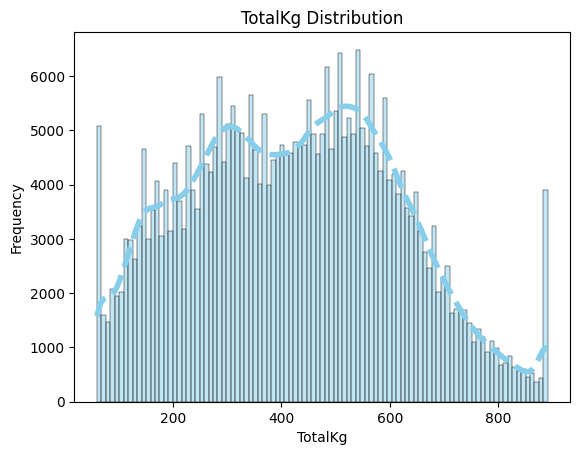

In [ ]:
sns.histplot(df['TotalKg'],color='skyblue',kde=True,line_kws={'color': 'Black', 'linewidth': 4, 'linestyle': 'dashed'})
plt.title('TotalKg Distribution')
plt.xlabel('TotalKg')
plt.ylabel('Frequency')
#The TotalKg distribution exhibits a multimodal structure with a slight positive (right) skew,
#indicating the presence of distinct sub-populations such as age and sex categories.
#While the bulk of the data reflects standard competitive levels,
#the extended right tail represents elite outliers. Furthermore,
#the frequency spikes at the distribution boundaries suggest data censoring or clipping,
#which should be considered during model evaluation to avoid biased predictions at the extremes

Text(0, 0.5, 'Frequency')

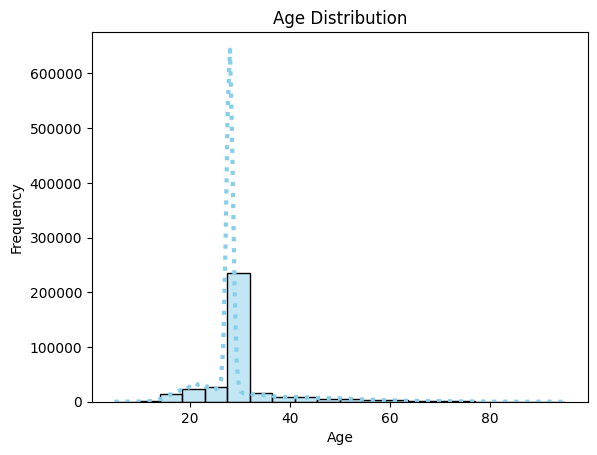

In [ ]:
sns.histplot(df['Age'],color='skyblue',kde=True,line_kws={'color': 'blue', 'linewidth': 3, 'linestyle': 'dotted'})
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
#"The Age distribution is highly unimodal and leptokurtic,
# characterized by an extreme concentration of data points around the 25–30 age range.
# The distribution exhibits a significant positive (right) skew, with a long tail extending toward older athletes (up to age 90), though these represent a very small fraction of the total population.
# This suggests the model will be highly specialized in predicting strength for athletes in their late 20s, but may have less 'experience' with much younger or much older lifters."

Text(0, 0.5, 'Frequency')

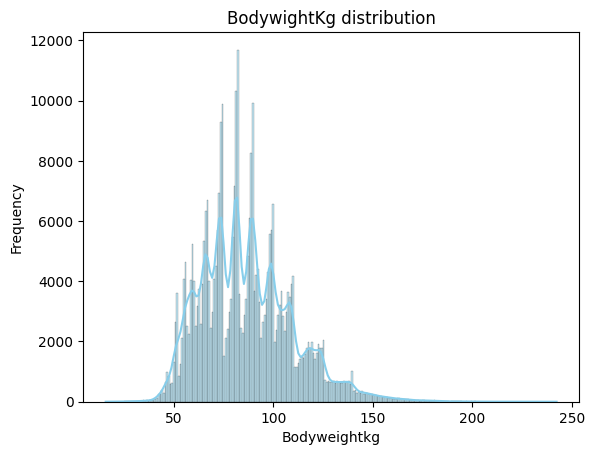

In [ ]:
sns.histplot(df['BodyweightKg'],color='skyblue',kde=True)
plt.title('BodywightKg distribution')
plt.xlabel('Bodyweightkg')
plt.ylabel('Frequency')
#"The BodyweightKg distribution is multimodal and right-skewed,
# with prominent frequency spikes that correspond directly to standard powerlifting weight classes.
# The concentration of data between 60kg and 100kg represents the most populated competitive categories,
# while the extended right tail indicates the presence of Super Heavyweight outliers.
# This structure confirms that bodyweight in this dataset is not just a biological variable,
# but one heavily influenced by the regulatory constraints of the sport."

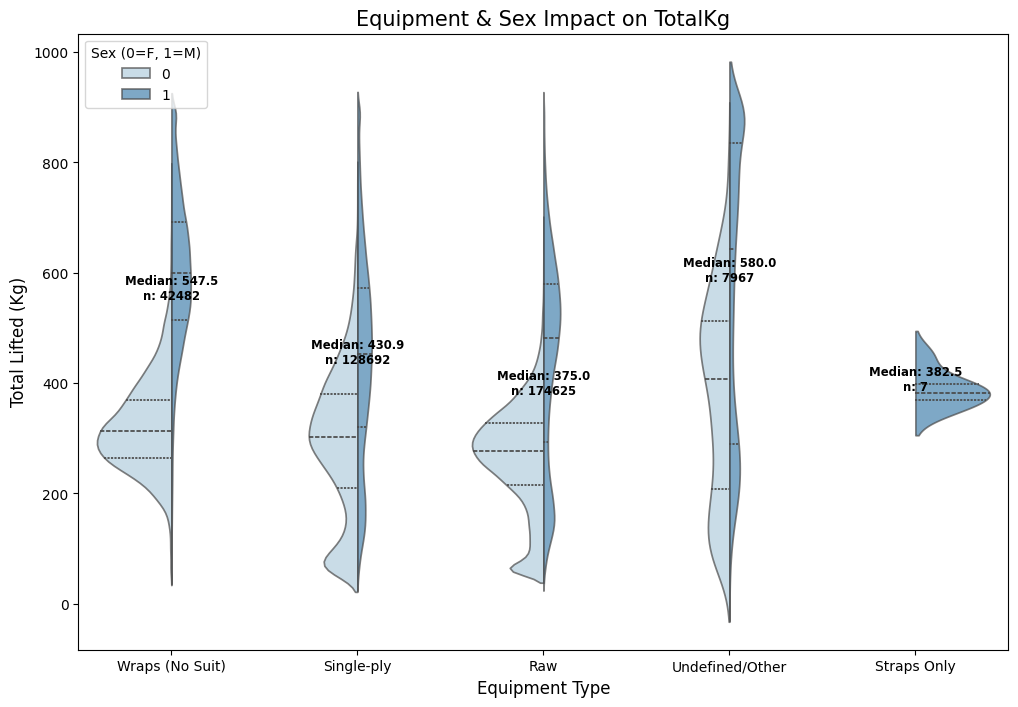

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup the figure
plt.figure(figsize=(12, 8))

# Prioritize categories: Raw > Single-ply > Wraps > Straps. If none, then 'Undefined/Other'.
conditions = [
    df['Equipment_Raw'] == 1,
    df['Equipment_Single-ply'] == 1,
    (df['Equipment_Raw'] == 0) & (df['Equipment_Single-ply'] == 0) & (df['Equipment_Wraps'] == 1),
    (df['Equipment_Raw'] == 0) & (df['Equipment_Single-ply'] == 0) & (df['Equipment_Wraps'] == 0) & (df['Equipment_Straps'] == 1)
]
choices = ['Raw', 'Single-ply', 'Wraps (No Suit)', 'Straps Only']
df['Equipment_Type'] = np.select(conditions, choices, default='Undefined/Other')


# 2. Create a Split Violin Plot I chosed violin instead of boxplot
# This shows the distribution density (the 'fatness' of the curve)
# and the boxplot inside it at the same time.
ax = sns.violinplot(x='Equipment_Type', y='TotalKg', hue='Sex',
                    data=df, split=True, inner="quart",
                    palette="Blues", alpha=0.7)

# 3. Add Statistical Labels for insight
# his calculates the median for each group and writes it on the chart
# Fix 3: Calculate medians and counts for each Equipment_Type (ignoring sex )
# and revise the loop for placing labels
overall_medians = df.groupby('Equipment_Type')['TotalKg'].median()
overall_nobs = df.groupby('Equipment_Type')['TotalKg'].count()

for i, label_obj in enumerate(ax.get_xticklabels()):
    equipment_type_label = label_obj.get_text()
    if equipment_type_label in overall_medians.index:
        median_val = overall_medians[equipment_type_label]
        count_val = overall_nobs[equipment_type_label]
        ax.text(i, median_val + 5, f'Median: {median_val:.1f}\nn: {count_val}',
                horizontalalignment='center', size='small', color='black', weight='semibold')

# 4. Final Formatting
plt.title('Equipment & Sex Impact on TotalKg', fontsize=15)
plt.ylabel('Total Lifted (Kg)', fontsize=12)
plt.xlabel('Equipment Type', fontsize=12)
plt.legend(title='Sex (0=F, 1=M)', loc='upper left')

plt.show()

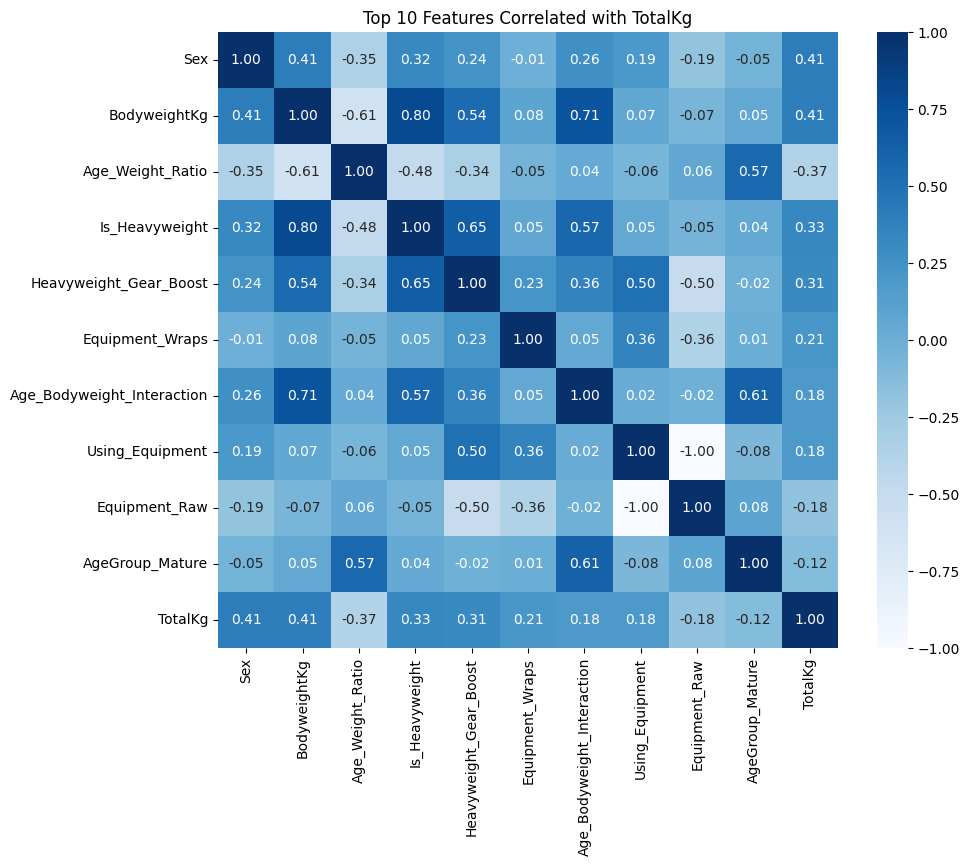

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_top_correlations(df, target='TotalKg', top_n=10):
    # Keep only numeric columns
    df_num = df.select_dtypes(include=['number'])

    # Compute correlations with target
    corr = df_num.corr()[target].drop(target)

    # Get top N strongest correlations (absolute)
    top_features = corr.abs().sort_values(ascending=False).head(top_n).index

    # Include target itself
    selected_cols = list(top_features) + [target]

    # Correlation matrix
    corr_matrix = df_num[selected_cols].corr()

    # Plot heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f",cmap="Blues")
    plt.title(f"Top {top_n} Features Correlated with {target}")
    plt.show()

# Run it
plot_top_correlations(df)

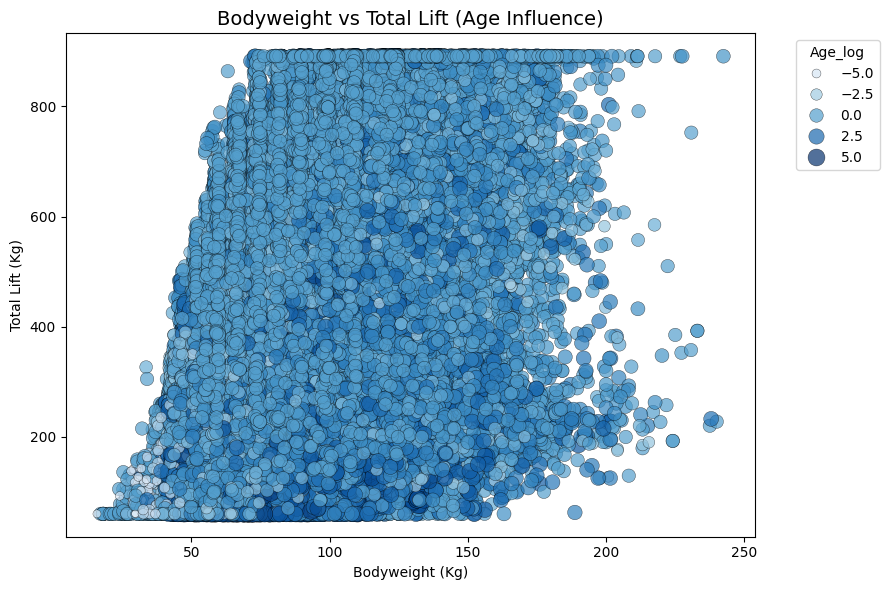

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def scatter_blue_professional(df):
    plt.figure(figsize=(9,6))

    sns.scatterplot(
        data=df,
        x='BodyweightKg',
        y='TotalKg',
        hue='Age_log',          #color based on Age_log
        size='Age_log',         #size also based on Age_log
        palette='Blues',        #blue shades
        sizes=(20, 150),
        alpha=0.7,
        edgecolor='black',
        linewidth=0.3
    )

    plt.title("Bodyweight vs Total Lift (Age Influence)", fontsize=14)
    plt.xlabel("Bodyweight (Kg)")
    plt.ylabel("Total Lift (Kg)")

    plt.legend(title='Age_log', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    plt.show()

# run
scatter_blue_professional(df)    # Used 'Age_log' for better modeling.
#"A bivariate analysis of Bodyweight and Total Lift demonstrates a clear positive correlation,
# with the density of the population concentrated in the 60–100kg bodyweight range.
# The inclusion of Age_log as a hue highlights that peak performance is distributed across various age maturities.
# Notably, the horizontal 'plateau' at 900kg suggests data censoring at the upper bound.
# This visualization justifies the use of a regression model, as the linear trend is evident,
# though the high variance suggests that interaction features (like Age_Bodyweight_Interaction) will be necessary to capture the nuances of individual performance."

In [ ]:
import pandas as pd

def groupby_target_summary(df, category, target='TotalKg'):  # My sister told my about this method
    # Group and compute mean
    summary = (
        df.groupby(category)[target]
        .mean()
        .sort_values(ascending=False)
        .round(2)
    )

    # Extract top & bottom
    highest = summary.idxmax()
    lowest = summary.idxmin()

    print(f" Mean {target} by {category}:\n")
    print(summary)

    print("\n Highest group:")
    print(f"{highest} → {summary[highest]} kg")

    print("\n Lowest group:")
    print(f"{lowest} → {summary[lowest]} kg")

    return summary

# Examples
groupby_target_summary(df, 'Sex')
groupby_target_summary(df, 'Equipment_Type')

 Mean TotalKg by Sex:

Sex
1    467.43
0    278.00
Name: TotalKg, dtype: float64

 Highest group:
1 → 467.43 kg

 Lowest group:
0 → 278.0 kg
 Mean TotalKg by Equipment_Type:

Equipment_Type
Undefined/Other    550.60
Wraps (No Suit)    533.63
Single-ply         427.77
Raw                388.45
Straps Only        388.21
Name: TotalKg, dtype: float64

 Highest group:
Undefined/Other → 550.6 kg

 Lowest group:
Straps Only → 388.21 kg


,TotalKg
Equipment_Type,
Undefined/Other,550.60
Wraps (No Suit),533.63
Single-ply,427.77
Raw,388.45
Straps Only,388.21


## **Math Basics SECTION **


In [ ]:
# 1. Calculating ' std ' and ' mean ' ONLY NUMPY
import numpy as np

def compute_target_stats(df, target='TotalKg'):
    x = df[target].values   # convert to NumPy array

    # Mean
    mean = np.sum(x) / len(x)

    # Standard Deviation (population)
    variance = np.sum((x - mean) ** 2) / len(x)
    std = np.sqrt(variance)

    print(f"Mean {target}: {mean:.2f}")
    print(f"Std {target}: {std:.2f}")

    return mean, std

# Run
compute_target_stats(df)

Mean TotalKg: 423.84
Std TotalKg: 192.90


(np.float64(423.8391981016075), np.float64(192.89570880710585))

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

def standardize_and_compare(df, column='BodyweightKg'):
    x = df[column].values.reshape(-1, 1)  # make it 2D

    #Manual standardization
    mean = np.mean(x)
    std = np.std(x)
    z_manual = (x - mean) / std

    #Sklearn standardization
    scaler = StandardScaler()
    z_sklearn = scaler.fit_transform(x)

    #Compare
    difference = np.abs(z_manual - z_sklearn)
    max_diff = np.max(difference)

    print(f"Mean: {mean:.4f}")
    print(f"Std: {std:.4f}")
    print(f"Max difference between manual & sklearn: {max_diff:.10f}")

    return z_manual, z_sklearn

# Run
z_manual, z_sklearn = standardize_and_compare(df, 'BodyweightKg')

Mean: 86.6964
Std: 22.9897
Max difference between manual & sklearn: 0.0000000000


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

# 1. Identify your high and low indices
high_idx = df['TotalKg'].idxmax()
low_idx = df['TotalKg'].idxmin()

# 2. Select only the features you want to compare
# (Excluding IDs or non-numeric strings)
features = ['Age', 'BodyweightKg', 'Sex', 'TotalKg', 'Age_log', 'Age_Weight_Ratio']

# 3. CRITICAL: Scale the data first so one feature doesn't dominate
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features])
scaled_df = pd.DataFrame(scaled_data, index=df.index, columns=features)

# 4. Extract the vectors
vec_high = scaled_df.loc[[high_idx]]
vec_low = scaled_df.loc[[low_idx]]

# 5. Compute Similarity
sim = cosine_similarity(vec_high, vec_low)[0][0]

print(f"Highest TotalKg index: {high_idx}")
print(f"Lowest TotalKg index: {low_idx}")
print(f"Meaningful Cosine Similarity: {sim:.4f}")   # Amazing results, my features are pointing in the opposite direction

Highest TotalKg index: 45
Lowest TotalKg index: 67
Meaningful Cosine Similarity: -0.5803


In [ ]:
# 1. Define 'High Quality' as the Top 25% of lifters by Ratio
# This ensures we always have a 'High Quality' group to analyze
quality_cutoff = df['Age_Weight_Ratio'].quantile(0.75)
high_quality_filter = df['Age_Weight_Ratio'] >= quality_cutoff

# 2. Define a Target Threshold (e.g., lifting more than the average/median)
target_threshold = df['TotalKg'].median()

# 3. Filter and Calculate
high_quality_df = df[high_quality_filter]
success_count = len(high_quality_df[high_quality_df['TotalKg'] > target_threshold])
probability = success_count / len(high_quality_df)

print(f"...Probability Analysis...")
print(f"High-Quality Cutoff (Top 25% Ratio): {quality_cutoff:.4f}")
print(f"Target Milestone: > {target_threshold:.2f} kg")
print(f"Probability: {probability:.2%}")

...Probability Analysis...
High-Quality Cutoff (Top 25% Ratio): 0.4172
Target Milestone: > 425.00 kg
Probability: 20.38%


"Our probability analysis yielded a result of $20.38\%$, revealing a clear distinction between relative efficiency and absolute strength. While the top $25\%$ of lifters (by Age-Weight Ratio) are highly efficient, the majority do not exceed the median TotalKg. This confirms that our model must treat bodyweight as a primary weight-bearing factor rather than relying solely on ratios, as absolute power is heavily concentrated in the lower-ratio, higher-mass segments of the population." good thing!

/tmp/ipykernel_5044/667574741.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Using_Equipment', y='TotalKg', ax=axes[1, 0], palette='Set2')


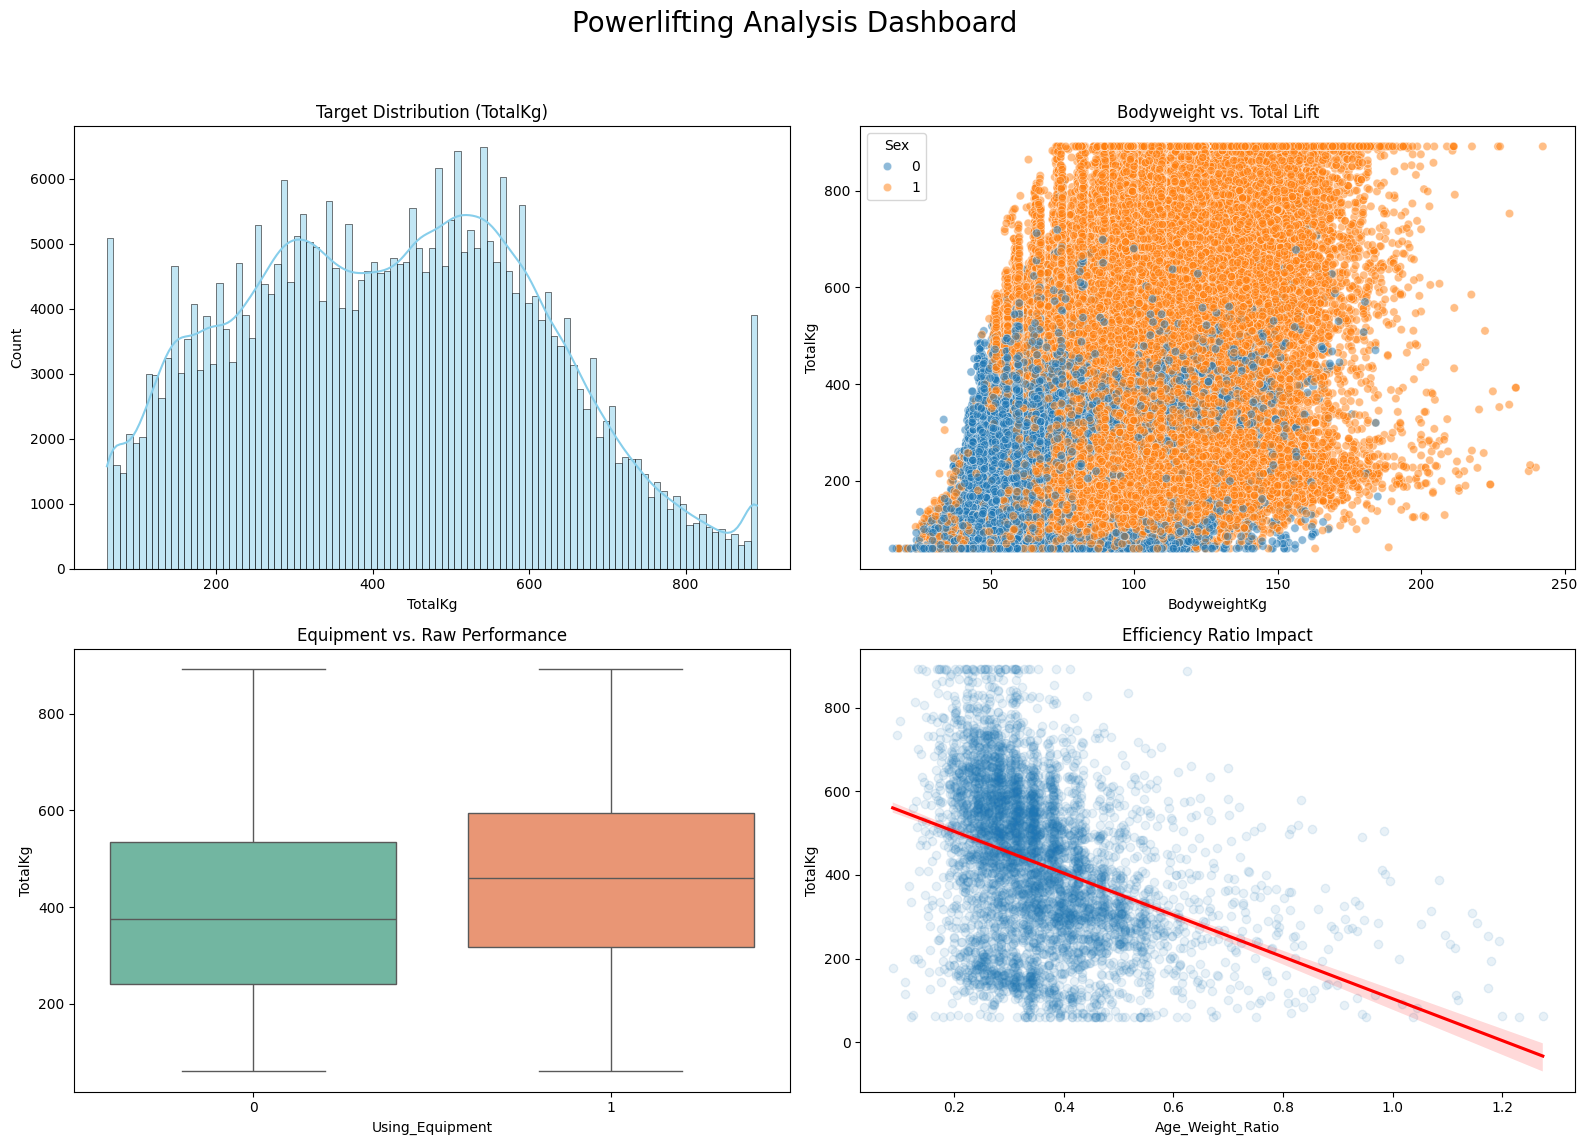

In [ ]:
# Half part of the bonus section
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Powerlifting Analysis Dashboard', fontsize=20)

# Chart 1: Distribution of TotalKg
sns.histplot(df['TotalKg'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Target Distribution (TotalKg)')

# Chart 2: Bodyweight vs TotalKg (by Sex)
sns.scatterplot(data=df, x='BodyweightKg', y='TotalKg', hue='Sex', alpha=0.5, ax=axes[0, 1])
axes[0, 1].set_title('Bodyweight vs. Total Lift')

# Chart 3: Impact of Equipment
sns.boxplot(data=df, x='Using_Equipment', y='TotalKg', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Equipment vs. Raw Performance')

# Chart 4: Age-Weight Ratio Correlation
sns.regplot(data=df.sample(5000), x='Age_Weight_Ratio', y='TotalKg',
            scatter_kws={'alpha':0.1}, line_kws={'color':'red'}, ax=axes[1, 1])
axes[1, 1].set_title('Efficiency Ratio Impact')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()